In [1]:
import paramiko
import time
import re
import subprocess
import os
import glob
from pathlib import Path
from IPython.display import HTML

# Define paths

In [2]:
#main_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce36/2025-11-09_pAce36_BL/Awake' # Finished, good
#main_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce21/2025-06-30_pAce21_PR/Awake' # Finished, good
#main_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce21/2025-07-09_pAce21_PR/Awake' # In progress
#main_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce9/2025-02-10_pAce9-PX/post-cement/awake/fov1' # In progress, SST INs
#main_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce9/2025-02-13_pAce9_WX/Awake' # SST INs

#main_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/SLM_pattern/2025-11-17_SLM/Surgc_R1' # Done, bad
#main_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce36/2025-11-09_pAce36_BL/Awake' # Done. Okay
#main_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce37/2025-11-12_pAce37_BR/post/Awake' # Finished
#main_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce37/2025-11-11_pAce37_BX/post/Awake' # Done, bad

#main_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce22/2025-06-04_pAce22_PX/Awake' # Finished, good
#main_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce19/2025-04-21_pAce19/PX/Awake/FOV1'# Finished, good
#main_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce17/2025-03-26_pAce17/PX/short-lens/post-cement/Awake'
#main_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce38/2025-11-26_pAce38/PX/post/Awake'

#main_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce42/2025-12-24_pAce42/PR/post/Awake'


#main_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce38/2025-12-28_pAce38/PR/Awake'
#main_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce775/2025-12-31_775_PR/post/Awake'
#main_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce45/2026-01-18_pAce45/PX/post/Awake'
#main_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-01-26_pAce46_BL/post/Awake'
#main_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake'


#main_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce21/2025-08-06_pAce21_PR/Awake' # Finished, good, 10 mins, need downsample
#main_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce38/2025-11-26_pAce38/PX/post/Awake' # 4X4
#main_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce45/2026-01-18_pAce45/PX/post/Awake' # 4X4
main_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake' # 4X4




only_good = True
# Grab subfolders
if only_good:
    data_folders = [folder for folder in glob.glob(os.path.join(main_folder, '*good*')) if os.path.isdir(folder)]
else:
    data_folders = [folder for folder in glob.glob(os.path.join(main_folder, '*')) if os.path.isdir(folder)]
# sort folders by name
data_folders.sort()

print(f"Found {len(data_folders)} data folders.")
for folder in data_folders:
    print(f"Found folder: {folder}")
    folder = Path(folder)
    HTML(f'<a href="{folder.as_uri()}" target="_blank">📁 Open in Finder</a>')
    # Here you can add any processing you want to do with each folder

# within each folder, there's a subfolder that does not contain "TS_" in its name, within it there should be a '.raw' file, get it

data_file_paths = []
for folder in data_folders:
    subfolders = [subfolder for subfolder in glob.glob(os.path.join(folder, '*')) if os.path.isdir(subfolder) and "TS_" not in os.path.basename(subfolder)]
    # sort subfolders by name
    subfolders.sort()
    if subfolders:
        target_subfolder = subfolders[0]
        raw_files = glob.glob(os.path.join(target_subfolder, 'Image_001_001.raw'))
        data_file_paths.extend(raw_files)
        if raw_files:
            print(f"Found .raw files: {raw_files}")
        else:
            print(f"no .raw files found in {target_subfolder}")
    else:
        print(f"In folder {folder}, no target subfolder found.")

data_file_paths = [path.replace('/Volumes/adam-lab', '/ems/elsc-labs/adam-y') for path in data_file_paths]
print("Final list of .raw file paths:")
for path in data_file_paths:
    print(path)
    

Found 2 data folders.
Found folder: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/2-good
Found folder: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/3-good
Found .raw files: ['/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/2-good/80mwmm-10min/Image_001_001.raw']
Found .raw files: ['/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/3-good/80mwmm-10min/Image_001_001.raw']
Final list of .raw file paths:
/ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/2-good/80mwmm-10min/Image_001_001.raw
/ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/3-good/80mwmm-10min/Image_001_001.raw


In [3]:
# Define cluster login details
CLUSTER_HOST = "loginserver.elsc.huji.ac.il"
USERNAME = "qixin.yang"
SSH_KEY_PATH = "/Users/qixinyang/.ssh/id_rsa.pub"  # Change this to your actual SSH key path
PASSWORD = 'C8!n.isr'

# Legacy runner (kept for older steps in this notebook)
sh_script_generic = "/ems/elsc-labs/adam-y/qixin.yang/ClusterCode/run_generic.sh"

# Pipeline_Final generic python runner (supports arbitrary args)
PIPELINE_WORKDIR = "/ems/elsc-labs/adam-y/qixin.yang/ClusterCode/miniVI_Renana_Pipeline"
sh_script_py = "/ems/elsc-labs/adam-y/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/utils/run_python_job.sh"

# Default to new runner unless a step opts into sh_script_py
sh_script = sh_script_py

# Create SSH client
ssh = paramiko.SSHClient()
ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())
ssh.connect(CLUSTER_HOST, username=USERNAME, key_filename=SSH_KEY_PATH)
print("[INFO] Connected to cluster using SSH key.")


[INFO] Connected to cluster using SSH key.


In [4]:
def run_command(command):
    """Runs a command on the cluster with an interactive shell"""
    full_command = f"bash -l -c '{command}'"
    stdin, stdout, stderr = ssh.exec_command(full_command)
    output = stdout.read().decode().strip()
    error = stderr.read().decode().strip()
    return output, error


# Step 1: Downsample + Motion Correction

[DS_motion_correction.py](/Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/utils/DS_motion_correction.py)


In [ ]:
python_script = "utils/DS_motion_correction.py"
JOB_NAME = "DS_motion_correction"

# Step1 outputs go to: <raw_parent>/<OUTPUT_SUBDIR>/<RUN_TAG>/
OUTPUT_SUBDIR = "output_final"
# Set to None to write directly into <raw_parent>/<OUTPUT_SUBDIR>/ (no per-run subfolder)
RUN_TAG = None

# Change these as needed
DOWNSAMPLE_FACTOR = (1,1)  # (H, W)
# NOTE: --preserve-sub1hz disables additive drift regression (alpha_t * P subtraction)
# and motion-regression denoising. Set False if you want alpha exp-decay fitting.
PRESERVE_SUB1HZ = False

# Additive drift regression alpha(t) modeling
ALPHA_SMOOTHING = "median"  # {"exp_decay", "median", "none"}
ALPHA_EXP_MIN_R2 = 0.05
ALPHA_EXP_FALLBACK = "disabled"  # {"disabled", "median"}
ALPHA_MEDIAN_MS = 10000  # used only when ALPHA_SMOOTHING == "median"

# Also apply the computed shifts to the raw saved movie tif (<filename>_movie.tif)
APPLY_SHIFTS_TO_RAW = True

# Motion-regression denoising (if enabled): larger chunk preserves slow signals better
MOTION_REG_CHUNK_SIZE = 30000 # in frames, this is about 1 minute at 500Hz

# Step1 preview generation (side-by-side). Set False to skip in Step1 and run Step 1.5 later.
MAKE_STEP1_PREVIEWS = False

LOG_DIR = f"{PIPELINE_WORKDIR}/logs"
LOG_DIR_LOCAL = LOG_DIR.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')
CLEAN_OLD_LOGS = True

# Ensure logs directory exists on the cluster before submitting (Slurm won't create it for --output/--error)
_, mkdir_err = run_command(f"mkdir -p {LOG_DIR}")
if mkdir_err:
    print(f"[WARN] Failed to create log dir on cluster: {mkdir_err}")

if CLEAN_OLD_LOGS:
    active_out, active_err = run_command(f"squeue -h -u {USERNAME} -n {JOB_NAME} -o %i")
    if active_err:
        print(f"[WARN] Could not query squeue for active jobs: {active_err}")
        active_ids = set()
    else:
        active_ids = {line.strip() for line in active_out.splitlines() if line.strip().isdigit()}

    files_out, _ = run_command(
        f"find {LOG_DIR} -maxdepth 1 -type f \\(" 
        f" -name \"{JOB_NAME}_*.out\" -o -name \"{JOB_NAME}_*.err\" \\) -print"
    )
    log_files = [p.strip() for p in files_out.splitlines() if p.strip()]

    stale = []
    for p in log_files:
        m = re.search(rf"{re.escape(JOB_NAME)}_(\\d+)\\.(out|err)$", os.path.basename(p))
        if m and (m.group(1) not in active_ids):
            stale.append(p)

    if stale:
        print(f"[INFO] Deleting {len(stale)} stale log files from {LOG_DIR_LOCAL}")
        chunk_size = 200
        for i in range(0, len(stale), chunk_size):
            chunk = stale[i : i + chunk_size]
            _, rm_err = run_command("rm -f " + " ".join(chunk))
            if rm_err:
                print(f"[WARN] rm returned error: {rm_err}")
    else:
        print(f"[INFO] No stale log files to delete in {LOG_DIR_LOCAL}")

print(f"[INFO] Slurm logs directory (local): {LOG_DIR_LOCAL}")

job_ids = []
for data_file in data_file_paths:
    cmd = (
        f"sbatch --job-name {JOB_NAME} --chdir {PIPELINE_WORKDIR} "
        f"--output {LOG_DIR}/%x_%j.out --error {LOG_DIR}/%x_%j.err "
        f"{sh_script_py} {PIPELINE_WORKDIR} {python_script} {data_file} "
        f"--factor {DOWNSAMPLE_FACTOR[0]} {DOWNSAMPLE_FACTOR[1]} "
        f"--output-subdir {OUTPUT_SUBDIR}"
    )
    if RUN_TAG:
        cmd += f" --run-tag {RUN_TAG}"
    if PRESERVE_SUB1HZ:
        cmd += " --preserve-sub1hz"

    cmd += f" --alpha-smoothing {ALPHA_SMOOTHING}"
    if ALPHA_SMOOTHING == "median":
        cmd += f" --alpha-median-ms {ALPHA_MEDIAN_MS}"
    elif ALPHA_SMOOTHING == "exp_decay":
        cmd += f" --alpha-exp-min-r2 {ALPHA_EXP_MIN_R2}"
        cmd += f" --alpha-exp-fallback {ALPHA_EXP_FALLBACK}"

    if APPLY_SHIFTS_TO_RAW:
        cmd += " --apply-shifts-to-raw"

    cmd += f" --motion-reg-chunk-size {MOTION_REG_CHUNK_SIZE}"

    if not MAKE_STEP1_PREVIEWS:
        cmd += " --no-previews"

    output, error = run_command(cmd)

    if error:
        print(f"[ERROR] Failed to submit job for {data_file}: {error}")
    else:
        print(f"[INFO] Job submitted for {data_file}: {output}")
        match = re.search(r'Submitted batch job (\d+)', output)
        if match:
            job_id = match.group(1)
            job_ids.append(job_id)
            print(f"[INFO] Job ID: {job_id}")
            print(f"[INFO] Slurm .out (local): {LOG_DIR_LOCAL}/{JOB_NAME}_{job_id}.out")


[INFO] No stale log files to delete in /Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/logs
[INFO] Slurm logs directory (local): /Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/logs
[INFO] Job submitted for /ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/2-good/80mwmm-10min/Image_001_001.raw: Submitted batch job 15118477
[INFO] Job ID: 15118477
[INFO] Slurm .out (local): /Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/logs/DS_motion_correction_15118477.out
[INFO] Job submitted for /ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/3-good/80mwmm-10min/Image_001_001.raw: Submitted batch job 15118478
[INFO] Job ID: 15118478
[INFO] Slurm .out (local): /Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/logs/DS_motion_correction_15118478.out


## Step 1.5: Make preview videos (side-by-side)

This step generates the two debug preview videos from an already-analyzed `output_final/` folder:
- `*_preprocessed_vs_movReg_preview.tif` (preprocessed | movReg)
- `*_raw_vs_raw_mc_preview.tif` (raw | raw_mc; requires Step1 ran with `--apply-shifts-to-raw`)

In [7]:
python_script = "utils/DS_make_previews.py"
JOB_NAME = "DS_make_previews"
OUTPUT_SUBDIR = "output_final"
LOG_DIR = f"{PIPELINE_WORKDIR}/logs"
LOG_DIR_LOCAL = LOG_DIR.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')
CLEAN_OLD_LOGS = True

PREVIEW_SECONDS = 120.0
PREVIEW_FPS = 50.0
# Set to an integer frame index to manually choose where the preview starts (overrides auto dark-frame skipping)
PREVIEW_START = 1000
# Also create a combined 2x2 preview: top row raw|raw_mc, bottom row preprocessed|movReg
COMBINE_FOUR = True
# Also create movReg | movReg_denoised side-by-side preview (if movReg_denoised.tif exists)
MAKE_MOVREG_DENOISED = True
FORCE_PREVIEWS = False

# Build unique output folders from the raw file paths (cluster paths)
output_folders = sorted({os.path.join(os.path.dirname(p), OUTPUT_SUBDIR) for p in data_file_paths})
print(f"[INFO] Found {len(output_folders)} output folders")
for d in output_folders:
    print(d)
job_ids_step15 = []

for out_dir in output_folders:
    cmd = (
        f"sbatch --job-name {JOB_NAME} --chdir {PIPELINE_WORKDIR} "
        f"--output {LOG_DIR}/%x_%j.out --error {LOG_DIR}/%x_%j.err "
        f"{sh_script_py} {PIPELINE_WORKDIR} {python_script} {out_dir} "
        f"--preview-seconds {PREVIEW_SECONDS} --preview-fps {PREVIEW_FPS}"
    )
    if PREVIEW_START is not None:
        cmd += f" --preview-start {int(PREVIEW_START)}"
    if COMBINE_FOUR:
        cmd += " --combine-four"
    if MAKE_MOVREG_DENOISED:
        cmd += " --movreg-denoised"
    if FORCE_PREVIEWS:
        cmd += " --force"
    output, error = run_command(cmd)
    if error:
        print(f"[ERROR] Failed to submit Step 1.5 job for {out_dir}: {error}")
    else:
        print(f"[INFO] Step 1.5 job submitted for {out_dir}: {output}")
        match = re.search(r'Submitted batch job (\d+)', output)
        if match:
            job_id = match.group(1)
            job_ids_step15.append(job_id)
            print(f"[INFO] Job ID: {job_id}")
            print(f"[INFO] Slurm .out (local): {LOG_DIR_LOCAL}/{JOB_NAME}_{job_id}.out")

[INFO] Found 2 output folders
/ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/2-good/80mwmm-10min/output_final
/ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/3-good/80mwmm-10min/output_final
[INFO] Step 1.5 job submitted for /ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/2-good/80mwmm-10min/output_final: Submitted batch job 15118505
[INFO] Job ID: 15118505
[INFO] Slurm .out (local): /Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/logs/DS_make_previews_15118505.out
[INFO] Step 1.5 job submitted for /ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/3-good/80mwmm-10min/output_final: Submitted batch job 15118506
[INFO] Job ID: 15118506
[INFO] Slurm .out (local): /Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/logs/DS_make_previews_15118506.out


In [9]:
# check job status
print("\n[INFO] Checking job statuses...")

command = f"squeue --me"
output, error = run_command(command)


print(f"[INFO] Status:\n{output}")


[INFO] Checking job statuses...
[INFO] Status:
JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
          15118505   elscn.q DS_make_ qixin.ya  R       0:35      1 elscn-54
          15118506   elscn.q DS_make_ qixin.ya  R       0:35      1 elscn-54


# Step 2: Check ROIs and Manually draw ROIs

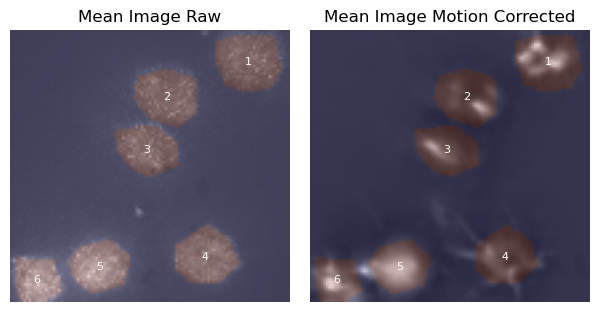

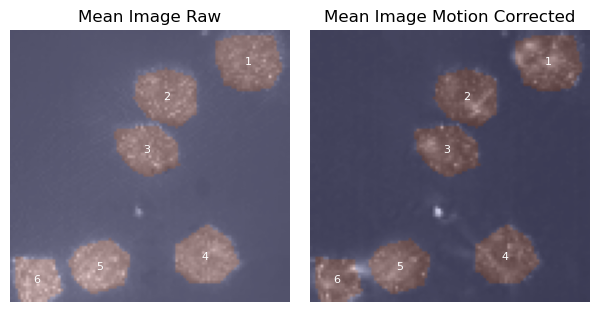

In [15]:
# Check ROIs
import glob
import os
import numpy as np
from tifffile import imread
import matplotlib.pyplot as plt

vmax = 0.95

OUTPUT_SUBDIR = globals().get('OUTPUT_SUBDIR', 'output_final')
RUN_TAG = globals().get('RUN_TAG', None)

def output_dir_for(raw_path_remote, output_subdir=OUTPUT_SUBDIR, run_tag=RUN_TAG):
    base = os.path.join(os.path.dirname(raw_path_remote), output_subdir)
    return os.path.join(base, run_tag) if run_tag else base

def _pick_latest(pattern):
    matches = glob.glob(pattern)
    if not matches:
        return None
    return max(matches, key=os.path.getmtime)

ROI_FILENAME = 'Image_001_001_ROIs.tif'

data_output_paths = []
for data_file in data_file_paths:
    out_dir = output_dir_for(data_file)

    # replace 'ems/elsc-labs/adam-y' with '/Volumes/adam-lab' to access local file system
    out_dir_local = out_dir.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')
    data_output_paths.append(out_dir_local)

    roi_file = os.path.join(out_dir_local, ROI_FILENAME)
    if not os.path.exists(roi_file):
        print(f'[WARN] Missing ROI file: {roi_file}')
        continue
    mean_img_raw_file = _pick_latest(os.path.join(out_dir_local, '*mean_image_raw*.tif'))
    mean_img_mc_file = _pick_latest(os.path.join(out_dir_local, '*mean_image_mc*.tif'))

    roi_img = imread(roi_file)
    roi_stack = roi_img if roi_img.ndim == 3 else roi_img[None, ...]
    roi_overlay = roi_stack.sum(axis=0)

    mean_img_raw = imread(mean_img_raw_file) if mean_img_raw_file else None
    mean_img_mc = imread(mean_img_mc_file) if mean_img_mc_file else None

    fig, axs = plt.subplots(1, 2, figsize=(6, 3), constrained_layout=True)
    if mean_img_raw is not None:
        axs[0].imshow(mean_img_raw, cmap='gray', vmin=0, vmax=float(mean_img_raw.max()) * vmax)
        axs[0].set_title('Mean Image Raw')
    else:
        axs[0].set_title('Mean Image Raw (missing)')
    axs[0].imshow(roi_overlay, cmap='jet', alpha=0.2)
    axs[0].axis('off')

    if mean_img_mc is not None:
        axs[1].imshow(mean_img_mc, cmap='gray', vmin=0, vmax=float(mean_img_mc.max()) * vmax)
        axs[1].set_title('Mean Image Motion Corrected')
    else:
        axs[1].set_title('Mean Image Motion Corrected (missing)')
    axs[1].imshow(roi_overlay, cmap='jet', alpha=0.2)
    axs[1].axis('off')

    for i in range(roi_stack.shape[0]):
        ys, xs = np.nonzero(roi_stack[i])
        if len(xs) and len(ys):
            x = float(xs.mean())
            y = float(ys.mean())
            axs[0].text(x, y, str(i + 1), color='white', fontsize=8, ha='center', va='center')
            axs[1].text(x, y, str(i + 1), color='white', fontsize=8, ha='center', va='center')

    plt.show()


In [17]:
# Call Streamlit app for batch ROI drawing
def run_ROI_app(output_paths):
    import subprocess
    import sys
    args = ['python', '../utils/DrawROI_GUI_batch.py'] + output_paths
    print("Running command:", ' '.join(args))
    subprocess.run(args)

run_ROI_app(data_output_paths)

Running command: python ../utils/DrawROI_GUI_batch.py /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/2-good/80mwmm-10min/output_final /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/3-good/80mwmm-10min/output_final


/Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/notebooks/../utils/DrawROI_GUI_batch.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl_cm.get_cmap("jet")


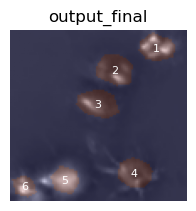

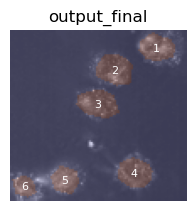

In [42]:
# Display manually drawn ROIs (if they exist)
import os
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread

V_MAX_FACTOR = 0.95

def _load_manual_rois(folder):
    npz_path = os.path.join(folder, 'manual_ROIs.npz')
    if not os.path.exists(npz_path):
        return None
    with np.load(npz_path, allow_pickle=True) as d:
        if 'ROIs' in d:
            rois = np.asarray(d['ROIs']).astype(bool)
        else:
            raise KeyError(f"Expected key 'ROIs' in {npz_path}")
    if rois.ndim == 2:
        rois = rois[None, ...]
    return rois

def _pick_latest(pattern):
    import glob
    matches = glob.glob(pattern)
    if not matches:
        return None
    return max(matches, key=os.path.getmtime)

if 'data_output_paths' not in globals():
    print('[WARN] data_output_paths is not defined (run the Step 2 setup cells first).')
else:
    for folder in data_output_paths:
        rois = _load_manual_rois(folder)
        if rois is None:
            print(f"[INFO] No manual_ROIs.npz in: {folder}")
            continue

        mean_mc_path = os.path.join(folder, 'mean_image_mc.tif')
        if not os.path.exists(mean_mc_path):
            mean_mc_path = _pick_latest(os.path.join(folder, '*mean_image_mc*.tif'))
        if not mean_mc_path:
            print(f"[WARN] Missing mean_image_mc.tif in: {folder}")
            continue

        mean_mc = imread(mean_mc_path)
        overlay = rois.sum(axis=0)

        fig, ax = plt.subplots(1, 1, figsize=(2,2), constrained_layout=True)
        vmax = float(np.max(mean_mc)) * float(V_MAX_FACTOR) if float(np.max(mean_mc)) > 0 else None
        ax.imshow(mean_mc, cmap='gray', vmin=0, vmax=vmax)
        ax.imshow(overlay, cmap='jet', alpha=0.2)
        ax.set_title(os.path.basename(folder))
        ax.axis('off')

        for i in range(rois.shape[0]):
            ys, xs = np.nonzero(rois[i])
            if xs.size and ys.size:
                ax.text(float(xs.mean()), float(ys.mean()), str(i + 1), color='white', fontsize=8,
                        ha='center', va='center')
        plt.show()


## Step 2.5: Masked motion-regression denoising (ROI-only)

This runs motion-regression denoising only inside your manual ROIs (`manual_ROIs.npz`).
It writes `movReg_denoised_masked.tif` into each `output_final` folder.

**Run after drawing ROIs (Step 2) and before Step 3.**

In [44]:
# Submit masked motion-regression jobs (per session)
python_script = "utils/motion_regression_masked.py"
LOG_DIR = f"{PIPELINE_WORKDIR}/logs"
LOG_DIR_LOCAL = LOG_DIR.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')
JOB_NAME = "masked_motion_reg"
MASKED_OUT_NAME = "movReg_denoised_masked.tif"
CHUNK_FRAMES = 300000 
PIXEL_BLOCK = 5000
DILATE_PX = 5
KEEP_OUTSIDE_MASK = False

# Ensure logs directory exists on the cluster
_, mkdir_err = run_command(f"mkdir -p {LOG_DIR}")
if mkdir_err:
    print(f"[WARN] Failed to create log dir on cluster: {mkdir_err}")

masked_job_ids = []
for data_file in data_file_paths:
    out_dir = os.path.join(os.path.dirname(data_file), OUTPUT_SUBDIR)
    if RUN_TAG:
        out_dir = os.path.join(out_dir, RUN_TAG)
    cmd = (
        f"sbatch --job-name {JOB_NAME} --mem=64G --chdir {PIPELINE_WORKDIR} "
        f"--output {LOG_DIR}/%x_%j.out --error {LOG_DIR}/%x_%j.err "
        f"{sh_script} {PIPELINE_WORKDIR} {python_script} {out_dir} "
        f"--out-name {MASKED_OUT_NAME} --chunk-frames {CHUNK_FRAMES} --pixel-block {PIXEL_BLOCK} "
        f"--dilate-px {DILATE_PX}"
    )
    if KEEP_OUTSIDE_MASK:
        cmd += " --keep-outside-mask"
    output, error = run_command(cmd)
    if error:
        print(f"[ERROR] Failed to submit masked motion-regression for {out_dir}: {error}")
    else:
        print(f"[INFO] Masked motion-regression job submitted for {out_dir}: {output}")
        match = re.search(r'Submitted batch job (\\d+)', output)
        if match:
            job_id = match.group(1)
            masked_job_ids.append(job_id)
            print(f"[INFO] Job ID: {job_id}")
            print(f"[INFO] Slurm .out (local): {LOG_DIR_LOCAL}/{JOB_NAME}_{job_id}.out")


[INFO] Masked motion-regression job submitted for /ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/2-good/80mwmm-10min/output_final: Submitted batch job 15119331
[INFO] Masked motion-regression job submitted for /ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/3-good/80mwmm-10min/output_final: Submitted batch job 15119332


In [45]:
# Make a side-by-side preview: movReg | movReg_denoised_masked (run after Step 2.5 completes)
python_script = "utils/DS_make_previews.py"
LOG_DIR = f"{PIPELINE_WORKDIR}/logs"
LOG_DIR_LOCAL = LOG_DIR.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')
JOB_NAME = "DS_make_previews_masked"

PREVIEW_SECONDS = 120.0
PREVIEW_FPS = 50.0
PREVIEW_START = 1000
FORCE_PREVIEWS = False

# Ensure logs directory exists on the cluster
_, mkdir_err = run_command(f"mkdir -p {LOG_DIR}")
if mkdir_err:
    print(f"[WARN] Failed to create log dir on cluster: {mkdir_err}")

preview_job_ids = []
for data_file in data_file_paths:
    out_dir = os.path.join(os.path.dirname(data_file), OUTPUT_SUBDIR)
    if RUN_TAG:
        out_dir = os.path.join(out_dir, RUN_TAG)
    cmd = (
        f"sbatch --job-name {JOB_NAME} --chdir {PIPELINE_WORKDIR} "
        f"--output {LOG_DIR}/%x_%j.out --error {LOG_DIR}/%x_%j.err "
        f"{sh_script} {PIPELINE_WORKDIR} {python_script} {out_dir} "
        f"--preview-seconds {PREVIEW_SECONDS} --preview-fps {PREVIEW_FPS} "
        f"--preview-start {int(PREVIEW_START)} --only-movreg --movreg-denoised-masked"
    )
    if FORCE_PREVIEWS:
        cmd += " --force"
    output, error = run_command(cmd)
    if error:
        print(f"[ERROR] Failed to submit preview job for {out_dir}: {error}")
    else:
        print(f"[INFO] Preview job submitted for {out_dir}: {output}")
        match = re.search(r'Submitted batch job (\\d+)', output)
        if match:
            job_id = match.group(1)
            preview_job_ids.append(job_id)
            print(f"[INFO] Job ID: {job_id}")
            print(f"[INFO] Slurm .out (local): {LOG_DIR_LOCAL}/{JOB_NAME}_{job_id}.out")


[INFO] Preview job submitted for /ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/2-good/80mwmm-10min/output_final: Submitted batch job 15119338
[INFO] Preview job submitted for /ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/3-good/80mwmm-10min/output_final: Submitted batch job 15119339


# Step 3: Demix (Chunked - Memory Efficient)

This approach splits videos by ROI to reduce memory usage:
1. **Chunk**: Split video into smaller crops around each ROI
2. **Process**: Run VolPy on each chunk as independent jobs
3. **Concatenate**: Merge all results back together

## Step 3a: Chunk videos by ROI

[chunk_video_by_ROI.py](/Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/utils/chunk_video_by_ROI.py)

This splits each video into smaller crops around each ROI with spatial padding.

In [46]:
new_data_extension = 'movReg_denoised_masked.tif'

mc_denoised_file_paths = []
for data_file in data_file_paths:
    out_dir = os.path.join(os.path.dirname(data_file), OUTPUT_SUBDIR)
    if RUN_TAG:
        out_dir = os.path.join(out_dir, RUN_TAG)
    denoised_file = os.path.join(out_dir, new_data_extension)
    denoised_file_local = denoised_file.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')
    if os.path.exists(denoised_file_local):
        print(f"Denoised file exists: {denoised_file_local}")
        mc_denoised_file_paths.append(denoised_file)
    else:
        print(f"Denoised file NOT found: {denoised_file_local}")


Denoised file exists: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/2-good/80mwmm-10min/output_final/movReg_denoised_masked.tif
Denoised file exists: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/3-good/80mwmm-10min/output_final/movReg_denoised_masked.tif


In [47]:
# Submit chunking jobs
python_script = "utils/chunk_video_by_ROI.py"
LOG_DIR = f"{PIPELINE_WORKDIR}/logs"
LOG_DIR_LOCAL = LOG_DIR.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')
JOB_NAME = "chunk_video"
DILATION = 10

# Ensure logs directory exists on the cluster
_, mkdir_err = run_command(f"mkdir -p {LOG_DIR}")
if mkdir_err:
    print(f"[WARN] Failed to create log dir on cluster: {mkdir_err}")

chunk_job_ids = []
for data_file in mc_denoised_file_paths:
    command = (
        f"sbatch --job-name {JOB_NAME} --chdir {PIPELINE_WORKDIR} "
        f"--output {LOG_DIR}/%x_%j.out --error {LOG_DIR}/%x_%j.err "
        f"{sh_script} {PIPELINE_WORKDIR} {python_script} {data_file} "
        f"--dilation {DILATION}"
    )
    output, error = run_command(command)
    if error:
        print(f"[ERROR] Failed to submit chunking job for {data_file}: {error}")
    else:
        print(f"[INFO] Chunking job submitted for {data_file}: {output}")
        match = re.search(r'Submitted batch job (\d+)', output)
        if match:
            job_id = match.group(1)
            chunk_job_ids.append(job_id)
            print(f"[INFO] Job ID: {job_id}")
            print(f"[INFO] Slurm .out (local): {LOG_DIR_LOCAL}/{JOB_NAME}_{job_id}.out")

[INFO] Chunking job submitted for /ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/2-good/80mwmm-10min/output_final/movReg_denoised_masked.tif: Submitted batch job 15119355
[INFO] Job ID: 15119355
[INFO] Slurm .out (local): /Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/logs/chunk_video_15119355.out
[INFO] Chunking job submitted for /ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/3-good/80mwmm-10min/output_final/movReg_denoised_masked.tif: Submitted batch job 15119356
[INFO] Job ID: 15119356
[INFO] Slurm .out (local): /Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/logs/chunk_video_15119356.out


In [48]:
# Wait for chunking jobs to complete
def wait_for_jobs(job_ids, poll_interval=30):
    """Poll SLURM until all jobs complete. Returns True if all succeeded."""
    import time
    from IPython.display import clear_output
    
    if not job_ids:
        print("No jobs to wait for.")
        return True
    
    pending_jobs = set(job_ids)
    failed_jobs = []
    
    while pending_jobs:
        # Check job status
        job_list = ','.join(pending_jobs)
        command = f"sacct -j {job_list} --format=JobID,State,ExitCode -n -P"
        output, error = run_command(command)
        
        if error and 'Invalid job id' not in error:
            print(f"[WARNING] Error checking jobs: {error}")
        
        # Parse output
        completed = set()
        for line in output.strip().split('\n'):
            if not line or '.' in line.split('|')[0]:  # Skip sub-jobs like "12345.batch"
                continue
            parts = line.split('|')
            if len(parts) >= 2:
                job_id, state = parts[0], parts[1]
                if state in ['COMPLETED', 'FAILED', 'CANCELLED', 'TIMEOUT']:
                    completed.add(job_id)
                    if state != 'COMPLETED':
                        failed_jobs.append((job_id, state))
        
        pending_jobs -= completed
        
        clear_output(wait=True)
        print(f"[{time.strftime('%H:%M:%S')}] Jobs status:")
        print(f"  Completed: {len(job_ids) - len(pending_jobs)}/{len(job_ids)}")
        print(f"  Pending: {len(pending_jobs)}")
        if failed_jobs:
            print(f"  Failed: {failed_jobs}")
        
        if pending_jobs:
            print(f"\nWaiting {poll_interval}s before next check...")
            time.sleep(poll_interval)
    
    print("\n" + "="*50)
    if failed_jobs:
        print(f"WARNING: {len(failed_jobs)} jobs failed: {failed_jobs}")
        return False
    else:
        print("All jobs completed successfully!")
        return True

# Wait for chunking jobs
wait_for_jobs(chunk_job_ids, poll_interval=5)

[12:57:18] Jobs status:
  Completed: 2/2
  Pending: 0

All jobs completed successfully!


True

## Step 3b: Submit VolPy jobs for each chunk

[demix_chunk.py](/Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/utils/demix_chunk.py)

**Wait for chunking jobs to complete before running this cell!**

In [49]:
# Collect all chunk video paths and submit demix jobs
python_script = "utils/demix_chunk.py"
LOG_DIR = f"{PIPELINE_WORKDIR}/logs"
LOG_DIR_LOCAL = LOG_DIR.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')
JOB_NAME = "demix_chunk"
DEMIX_MEM = "32G"

# Ensure logs directory exists on the cluster
_, mkdir_err = run_command(f"mkdir -p {LOG_DIR}")
if mkdir_err:
    print(f"[WARN] Failed to create log dir on cluster: {mkdir_err}")

demix_job_ids = []
for data_file in mc_denoised_file_paths:
    # Find all chunk directories
    data_folder = os.path.dirname(data_file)
    chunks_dir = os.path.join(data_folder, 'chunks')
    
    # List chunk directories
    command = f"ls -d {chunks_dir}/chunk_*/ 2>/dev/null"
    output, error = run_command(command)
    
    if error or not output:
        print(f"[WARNING] No chunks found for {data_file}")
        continue
    
    chunk_dirs = [d.rstrip('/') for d in output.strip().split('\n') if d.strip()]
    print(f"[INFO] Found {len(chunk_dirs)} chunks for {data_folder}")
    
    for chunk_dir in chunk_dirs:
        chunk_video = os.path.join(chunk_dir, 'movReg_denoised.tif')
        command = (
            f"sbatch --job-name {JOB_NAME} --mem={DEMIX_MEM} --chdir {PIPELINE_WORKDIR} "
            f"--output {LOG_DIR}/%x_%j.out --error {LOG_DIR}/%x_%j.err "
            f"{sh_script} {PIPELINE_WORKDIR} {python_script} {chunk_video}"
        )
        output, error = run_command(command)
        
        if error:
            print(f"[ERROR] Failed to submit job for {chunk_video}: {error}")
        else:
            print(f"[INFO] Job submitted for {chunk_video}: {output}")
            match = re.search(r'Submitted batch job (\d+)', output)
            if match:
                job_id = match.group(1)
                demix_job_ids.append(job_id)
                print(f"[INFO] Slurm .out (local): {LOG_DIR_LOCAL}/{JOB_NAME}_{job_id}.out")

print(f"\n[INFO] Total demix chunk jobs submitted: {len(demix_job_ids)}")

[INFO] Found 6 chunks for /ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/2-good/80mwmm-10min/output_final
[INFO] Job submitted for /ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/2-good/80mwmm-10min/output_final/chunks/chunk_0/movReg_denoised.tif: Submitted batch job 15119358
[INFO] Slurm .out (local): /Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/logs/demix_chunk_15119358.out
[INFO] Job submitted for /ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/2-good/80mwmm-10min/output_final/chunks/chunk_1/movReg_denoised.tif: Submitted batch job 15119359
[INFO] Slurm .out (local): /Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/logs/demix_chunk_15119359.out
[INFO] Job submitted for /ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/2-good/80mwmm-10min/output_final/chunks/chunk_2/

In [50]:
# Wait for demix chunk jobs
wait_for_jobs(demix_job_ids, poll_interval=10)

[13:00:05] Jobs status:
  Completed: 12/12
  Pending: 0
  Failed: [('15119358', 'FAILED'), ('15119359', 'FAILED'), ('15119360', 'FAILED'), ('15119362', 'FAILED'), ('15119363', 'FAILED'), ('15119364', 'FAILED'), ('15119366', 'FAILED'), ('15119367', 'FAILED'), ('15119368', 'FAILED'), ('15119369', 'FAILED'), ('15119361', 'FAILED'), ('15119365', 'FAILED')]



False

## Step 3c: Concatenate chunk results

[concat_chunk_results.py](/Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/utils/concat_chunk_results.py)

**Wait for ALL demix chunk jobs to complete before running this cell!**

In [51]:
# Submit concatenation jobs
python_script = "utils/concat_chunk_results.py"
LOG_DIR = f"{PIPELINE_WORKDIR}/logs"
LOG_DIR_LOCAL = LOG_DIR.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')
JOB_NAME = "concat_chunks"

# Ensure logs directory exists on the cluster
_, mkdir_err = run_command(f"mkdir -p {LOG_DIR}")
if mkdir_err:
    print(f"[WARN] Failed to create log dir on cluster: {mkdir_err}")

concat_job_ids = []
for data_file in mc_denoised_file_paths:
    data_folder = os.path.dirname(data_file)
    
    command = (
        f"sbatch --job-name {JOB_NAME} --chdir {PIPELINE_WORKDIR} "
        f"--output {LOG_DIR}/%x_%j.out --error {LOG_DIR}/%x_%j.err "
        f"{sh_script} {PIPELINE_WORKDIR} {python_script} {data_folder}"
    )
    output, error = run_command(command)
    
    if error:
        print(f"[ERROR] Failed to submit concat job for {data_folder}: {error}")
    else:
        print(f"[INFO] Concat job submitted for {data_folder}: {output}")
        match = re.search(r'Submitted batch job (\d+)', output)
        if match:
            job_id = match.group(1)
            concat_job_ids.append(job_id)
            print(f"[INFO] Job ID: {job_id}")
            print(f"[INFO] Slurm .out (local): {LOG_DIR_LOCAL}/{JOB_NAME}_{job_id}.out")

[INFO] Concat job submitted for /ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/2-good/80mwmm-10min/output_final: Submitted batch job 15119371
[INFO] Job ID: 15119371
[INFO] Slurm .out (local): /Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/logs/concat_chunks_15119371.out
[INFO] Concat job submitted for /ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/3-good/80mwmm-10min/output_final: Submitted batch job 15119372
[INFO] Job ID: 15119372
[INFO] Slurm .out (local): /Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/logs/concat_chunks_15119372.out


In [52]:
# Wait for concat jobs
wait_for_jobs(concat_job_ids, poll_interval=10)

[13:01:35] Jobs status:
  Completed: 2/2
  Pending: 0

All jobs completed successfully!


True

# Step 4: Spike Detection

In [53]:
new_data_extension = 'movReg_denoised_masked.tif'

mc_denoised_file_paths = []
for data_file in data_file_paths:
    out_dir = os.path.join(os.path.dirname(data_file), OUTPUT_SUBDIR)
    if RUN_TAG:
        out_dir = os.path.join(out_dir, RUN_TAG)
    denoised_file = os.path.join(out_dir, new_data_extension)
    denoised_file_local = denoised_file.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')
    if os.path.exists(denoised_file_local):
        print(f"Denoised file exists: {denoised_file_local}")
        mc_denoised_file_paths.append(denoised_file)
    else:
        print(f"Denoised file NOT found: {denoised_file_local}")


Denoised file exists: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/2-good/80mwmm-10min/output_final/movReg_denoised_masked.tif
Denoised file exists: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/3-good/80mwmm-10min/output_final/movReg_denoised_masked.tif


In [54]:
demixed_results = []
for data_file in mc_denoised_file_paths:
    demix_file = os.path.join(os.path.dirname(data_file), 'volpy_demix_results.pickle')
    demix_file_local = demix_file.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')
    if os.path.exists(demix_file_local):
        print(f"Demixed results file exists: {demix_file_local}")
        demixed_results.append(demix_file_local)
    else:
        print(f"Demixed results file NOT found: {demix_file}")

Demixed results file exists: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/2-good/80mwmm-10min/output_final/volpy_demix_results.pickle
Demixed results file exists: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/3-good/80mwmm-10min/output_final/volpy_demix_results.pickle


In [55]:
# def run_spike_detection_app(main_folder):
#     import subprocess
#     import sys
#     args = ['streamlit', 'run', '/Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/utils/SpikeDetectionAPP_Batch.py', '--', main_folder]
#     print("Running command:", ' '.join(args))
#     subprocess.run(args)

# run_spike_detection_app(main_folder)

[SpikeDetectionAPP_Concat.py](/Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/utils/SpikeDetectionAPP_Concat.py)

In [56]:
def run_spike_detection_app(main_folder):
    import subprocess
    import sys
    args = ['streamlit', 'run', '/Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/utils/SpikeDetectionAPP_Concat.py', '--', main_folder]
    print("Running command:", ' '.join(args))
    subprocess.run(args)

run_spike_detection_app(main_folder)

Running command: streamlit run /Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/utils/SpikeDetectionAPP_Concat.py -- /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://132.64.104.193:8501

  For better performance, install the Watchdog module:

  $ xcode-select --install
  $ pip install watchdog
            


2026-02-04 13:03:56.507 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-02-04 13:03:56.516 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-02-04 13:03:56.527 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-02-04 13:03:56.539 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-02-04 13:03:56.552 

  Stopping...


KeyboardInterrupt: 

# Step 6: Clean up intermediate files

In [9]:
# Remove all intermediate files to save space
for data_file in data_file_paths:
    out_dir = os.path.join(os.path.dirname(data_file), OUTPUT_SUBDIR)
    if RUN_TAG:
        out_dir = os.path.join(out_dir, RUN_TAG)
    out_dir_local = out_dir.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')

    print(f"Cleaning up intermediate files in {out_dir_local}...")

    movreg_file = os.path.join(out_dir_local, 'movReg.tif')
    movreg_denoised_file = os.path.join(out_dir_local, 'movReg_denoised.tif')
    movreg_denoised_masked_file = os.path.join(out_dir_local, 'movReg_denoised_masked.tif')
    all_mmap_files = glob.glob(os.path.join(out_dir_local, '*.mmap'))
    downsample_movie_file = glob.glob(os.path.join(out_dir_local, '*downsampled_movie*'))

    files_to_remove = [movreg_file, movreg_denoised_file, movreg_denoised_masked_file] + all_mmap_files + downsample_movie_file
    for file_path in files_to_remove:
        if os.path.exists(file_path):
            os.remove(file_path)
            print(f"Removed file: {file_path}")
        else:
            print(f"File not found, skipping: {file_path}")


Cleaning up intermediate files in /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce22/2025-06-04_pAce22_PX/Awake/2-good/150mwmm-180s-1/output...
Removed file: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce22/2025-06-04_pAce22_PX/Awake/2-good/150mwmm-180s-1/output/movReg.tif
Removed file: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce22/2025-06-04_pAce22_PX/Awake/2-good/150mwmm-180s-1/output/movReg_denoised.tif
Removed file: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce22/2025-06-04_pAce22_PX/Awake/2-good/150mwmm-180s-1/output/Reg_View.tif
Removed file: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce22/2025-06-04_pAce22_PX/Awake/2-good/150mwmm-180s-1/output/Image_001_001_downsampled_movie_preprocessed_rig__d1_93_d2_151_d3_1_order_F_frames_89500_.mmap
Removed file: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce22/2025-06-04_pAce22_PX/Awake/2-good/150mwmm-180s-1/output/Image_001_001_downsampled_movie_preprocessed.tif
File not found,

# Run DeepLabCut for behavior analysis

In [87]:
behavior_video_paths = []
for data_file in data_file_paths:
    
    data_file = os.path.dirname((os.path.dirname(data_file)))
    # replace 'ems/elsc-labs/adam-y' with '/Volumes/adam-lab' to access local file system
    data_file = data_file.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')
    # find the avi file in data_file folder
    avi_files = glob.glob(os.path.join(data_file, '*.avi'))
    if avi_files:
        print(f"Found behavior video: {avi_files[0]}")
        # replace '/Volumes/adam-lab' with '/ems/elsc-labs/adam-y' for cluster path
        avi_file_cluster_path = avi_files[0].replace('/Volumes/adam-lab', '/ems/elsc-labs/adam-y')
        behavior_video_paths.append(avi_file_cluster_path)
    else:
        print(f"No behavior video found in {data_file}")

Found behavior video: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce37/2025-11-11_pAce37_BX/post/Awake/3-good/Flir-11112025172029-0000.avi
Found behavior video: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce37/2025-11-11_pAce37_BX/post/Awake/4-good/Flir-11112025172428-0000.avi


In [80]:
python_script = "DLC_inference.py"
LOG_DIR = "/ems/elsc-labs/adam-y/qixin.yang/ClusterCode/logs"
JOB_NAME = "DLC_inference"

job_ids = []
for data_file in behavior_video_paths:
    command = f"sbatch {sh_script} {data_file} {python_script}"
    output, error = run_command(command)
    if error:
        print(f"[ERROR] Failed to submit job for {data_file}: {error}")
    else:
        print(f"[INFO] Job submitted for {data_file}: {output}")
        # Extract job ID from output
        match = re.search(r'Submitted batch job (\d+)', output)
        if match:
            job_id = match.group(1)
            job_ids.append(job_id)
            print(f"[INFO] Job ID: {job_id}")

[INFO] Job submitted for /ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce37/2025-11-12_pAce37_BR/post/Awake/3-good/Flir-11122025124119-0000.avi: Submitted batch job 5469146
[INFO] Job ID: 5469146
[INFO] Job submitted for /ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce37/2025-11-12_pAce37_BR/post/Awake/4-good/Flir-11122025124528-0000.avi: Submitted batch job 5469147
[INFO] Job ID: 5469147
[INFO] Job submitted for /ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce37/2025-11-12_pAce37_BR/post/Awake/6-good/Flir-11122025125500-0000.avi: Submitted batch job 5469148
[INFO] Job ID: 5469148
